In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# angle bounds for determining cis vs trans configurations

cislower = -90
cisupper = 50
translower = 100
transupper = 240

nsim = 10 # number of simulations

In [3]:
ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)
p_ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)

In [4]:
ctd_weights_combined = ctd_weights_combined_raw/ctd_weights_combined_raw.sum()
p_ctd_weights_combined = p_ctd_weights_combined_raw/p_ctd_weights_combined_raw.sum()

In [5]:
params = [{'sep':r'\s+', 'low_memory':False}, {'engine':'c'}][0]

SASA_unphos = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/analysis/hbonds/dat/surf.dat', **params)
SASA_phos = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/analysis/hbonds/dat/surf.dat', **params)

In [6]:
ctd_phos_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/analysis/turn/ctd_dihedral_Omega.dat', header=0, sep = r'\s+')
ctd_unphos_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/analysis/turn/ctd_dihedral_Omega.dat', header=0, sep = r'\s+')

In [7]:
df_360_phos = ctd_phos_omega_angles_raw # Create a new column to hold the 360-degree adjusted omega values
# loop through columns to convert numbers below -90
for col in df_360_phos:
    df_360_phos.loc[df_360_phos[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360_phos[col] = round(df_360_phos[col])  # Round angles to the nearest integer

df_360_unphos = ctd_unphos_omega_angles_raw # Create a new column to hold the 360-degree adjusted omega values
# loop through columns to convert numbers below -90
for col in df_360_unphos:
    df_360_unphos.loc[df_360_unphos[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360_unphos[col] = round(df_360_unphos[col])  # Round angles to the nearest integer

In [8]:
# retaining omega angle values
ctd_phos_omega_angles = df_360_phos.copy()
ctd_unphos_omega_angles = df_360_unphos.copy()

In [9]:
# labelling configurationgs of omega angles
temp_angles = ctd_phos_omega_angles.copy()

ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_phos_omega_angles[(ctd_phos_omega_angles.iloc[:,1:] != "cis") & (ctd_phos_omega_angles.iloc[:,1:] != "trans")] = "neither"

# labelling configurationgs of omega angles
temp_angles = ctd_unphos_omega_angles.copy()

ctd_unphos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_unphos_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_unphos_omega_angles[(ctd_unphos_omega_angles.iloc[:,1:] != "cis") & (ctd_unphos_omega_angles.iloc[:,1:] != "trans")] = "neither"

/tmp/ipykernel_1727598/3533782883.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
/tmp/ipykernel_1727598/3533782883.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_unphos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"


In [10]:
SASA_phos.head()

,#Frame,SA_00001,SA_00002,SA_00003,SA_00004,SA_00005,SA_00006,SA_00007,SA_00008,SA_00009,...,SA_00015,SA_00016,SA_00017,SA_00018,SA_00019,SA_00020,SA_00021,SA_00022,SA_00023,SA_00024
0,1,2157.0936,55.4316,132.7084,28.2503,40.9313,123.6935,177.2314,110.4554,43.2490,...,93.0831,3.4550,125.2042,56.7199,75.2378,128.1682,188.7835,104.1303,134.5105,28.7778
1,2,2163.5888,54.9531,127.7529,31.3534,45.8853,129.1535,177.5830,111.7335,48.5059,...,92.6687,5.1607,130.2965,57.2949,81.3542,124.4263,177.2200,101.3794,140.0929,23.3432
2,3,2165.5688,62.8375,126.5708,33.6164,41.8252,124.3157,178.5122,112.9273,55.3413,...,87.5836,9.1339,136.3379,53.1979,74.3822,125.4005,172.8945,102.1190,135.2781,18.0012
3,4,2175.2677,66.5181,131.0680,30.1599,38.4660,126.0034,185.1882,115.9002,54.3483,...,88.4040,5.2275,134.9295,57.9735,71.0334,124.5026,171.1479,104.4626,131.1285,26.5571
4,5,2176.4163,69.7015,131.9024,28.5254,38.5168,121.1518,179.9742,114.8958,48.7966,...,86.4911,4.3458,127.8432,65.0637,73.6963,125.0431,176.6282,103.3776,129.7348,32.2600


In [11]:
ser5_SASA_unphos = pd.DataFrame(SASA_unphos['SA_00014'])
ser5_SASA_phos = pd.DataFrame(SASA_phos['SA_00014'])

In [12]:
ser5_SASA_phos = ser5_SASA_phos.reset_index(drop=True)
ser5_SASA_phos_cistrans = ser5_SASA_phos.copy()
ser5_SASA_phos_cistrans['cis/trans/neither'] = ctd_phos_omega_angles['omega:14']

ser5_SASA_unphos = ser5_SASA_unphos.reset_index(drop=True)
ser5_SASA_unphos_cistrans = ser5_SASA_unphos.copy()
ser5_SASA_unphos_cistrans['cis/trans/neither'] = ctd_unphos_omega_angles['omega:14']

In [13]:
ser5_SASA_unphos_cistrans['weights'] = ctd_weights_combined[0]
ser5_SASA_phos_cistrans['weights'] = p_ctd_weights_combined[0]

In [14]:
ser5_SASA_unphos_cistrans

,SA_00014,cis/trans/neither,weights
0,111.4741,trans,5.568765e-09
1,113.6700,trans,1.472184e-08
2,114.8034,trans,9.697759e-09
3,114.2768,trans,3.353217e-08
4,112.1722,trans,8.338822e-09
...,...,...,...
48999995,97.7749,trans,1.317516e-08
48999996,98.6006,trans,1.811567e-08
48999997,99.5379,trans,3.887373e-08
48999998,100.7151,trans,2.536682e-08


# Phosphorylated

## Pro6 in cis

In [15]:
pmean_cis = np.average((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], weights=(ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['weights'])

pstd_cis = np.sqrt(np.cov((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], aweights=(ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['weights']))

print("pmean: {}".format(pmean_cis))
print("pstd: {}".format(pstd_cis))

pmean: 181.27427930259256
pstd: 19.968330402883012


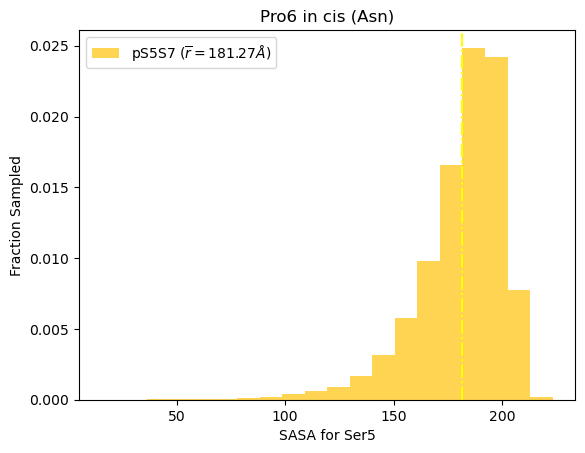

In [16]:
plt.hist((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], bins=20, weights = (ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True , color="#FFC20A", label=r"pS5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(pmean_cis, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_cis, color='yellow', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
plt.title('Pro6 in cis (Asn)')
plt.legend(loc="upper left", fontsize=10)
plt.show()

## Pro6 in trans

In [17]:
pmean_trans = np.average((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], weights=(ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['weights'])

pstd_trans = np.sqrt(np.cov((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], aweights=(ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['weights']))

print("pmean: {}".format(pmean_trans))
print("pstd: {}".format(pstd_trans))

pmean: 172.2918057330975
pstd: 24.56641201352292


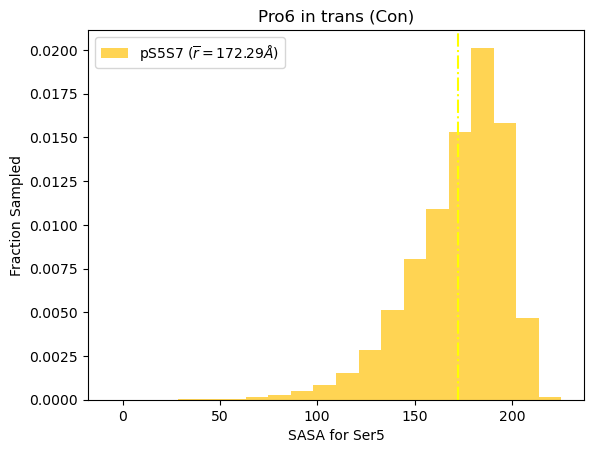

In [18]:
plt.hist((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], bins=20, weights = (ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#FFC20A", label=r"pS5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(pmean_trans, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_trans, color='yellow', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
plt.title('Pro6 in trans (Con)')
plt.legend(loc="upper left", fontsize=10)
plt.show()

## cis and trans together

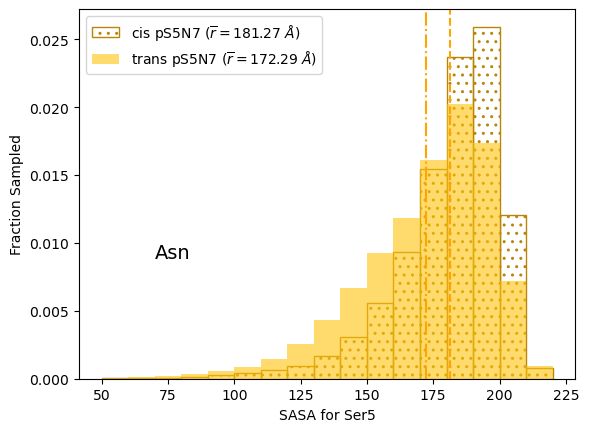

In [25]:
binedges = np.arange(50,225,10)

plt.figure()
plt.hist((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], bins=binedges, weights = (ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True, edgecolor="darkgoldenrod", color = '#FFC20A', fill=None, hatch='..', label=r"cis pS5N7 ($\overline{r} = $"+"{} $\AA$)".format(round(pmean_cis, 2)), alpha=1)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_cis, color='orange', ls='--')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')
plt.hist((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], bins=binedges, weights = (ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#FFC20A", label=r"trans pS5N7 ($\overline{r} = $"+"{} $\AA$)".format(round(pmean_trans, 2)), alpha=0.6)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_trans, color='orange', ls='-.')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
#plt.title('Asparagine Phosphorylated')
plt.legend(loc="upper left", fontsize=10)
plt.text(70, 0.01, 'Asn', fontsize=14, verticalalignment='top')
plt.show()

# Unphosphorylated

## Pro6 in cis

In [20]:
mean_cis = np.average((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], weights=(ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['weights'])

std_cis = np.sqrt(np.cov((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], aweights=(ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['weights']))

print("mean: {}".format(mean_cis))
print("std: {}".format(std_cis))

mean: 89.95471485692184
std: 24.470660161497875


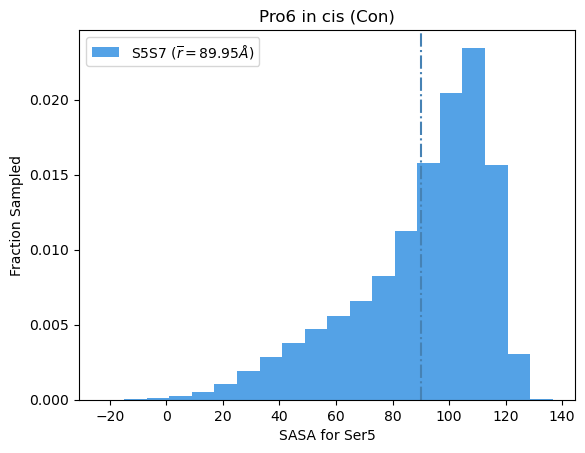

In [21]:
plt.hist((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], bins=20, weights = (ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True , color="#0C7BDC", label=r"S5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(mean_cis, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(mean_cis, color='steelblue', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{unphos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{ununphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD unphos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
plt.title('Pro6 in cis (Con)')
plt.legend(loc="upper left", fontsize=10)
plt.show()

## Pro6 in trans

In [22]:
mean_trans = np.average((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], weights=(ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['weights'])

std_trans = np.sqrt(np.cov((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], aweights=(ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['weights']))

print("mean: {}".format(mean_trans))
print("std: {}".format(std_trans))

mean: 74.24494205029323
std: 27.268736377204934


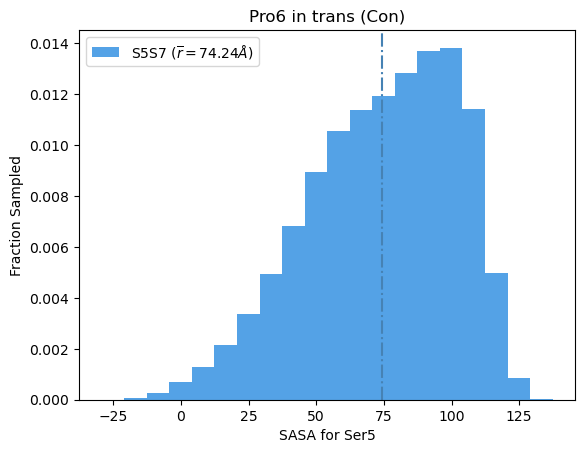

In [23]:
plt.hist((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], bins=20, weights = (ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#0C7BDC", label=r"S5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(mean_trans, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(mean_trans, color='steelblue', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{unphos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{ununphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD unphos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
plt.title('Pro6 in trans (Con)')
plt.legend(loc="upper left", fontsize=10)
plt.show()

## cis and trans together

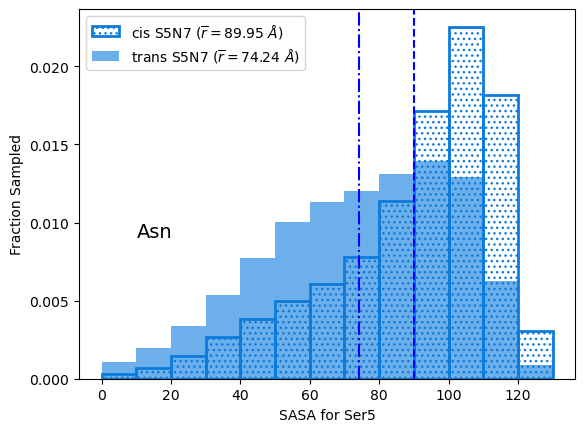

In [26]:
binedges = np.arange(0,135,10)

plt.hist((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], bins=binedges, weights = (ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True , color="#0C7BDC", linewidth=2, fill=None, hatch='...', edgecolor="#0C7BDC", label=r"cis S5N7 ($\overline{r} = $"+"{} $\AA$)".format(round(mean_cis, 2)), alpha=1)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(mean_cis, color='blue', ls='--')

plt.hist((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], bins=binedges, weights = (ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#0C7BDC", label=r"trans S5N7 ($\overline{r} = $"+"{} $\AA$)".format(round(mean_trans, 2)), alpha=0.6)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(mean_trans, color='blue', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{unphos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{ununphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD unphos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
#plt.title('Asparagine Unphosphorylated')
plt.legend(loc="upper left", fontsize=10)
plt.text(10, 0.01, 'Asn', fontsize=14, verticalalignment='top')
plt.show()